In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [53]:
# LOAD DATASETS

In [89]:
master_df = pd.read_csv("../outputs/master_analytics_dataset.csv")

In [75]:
# DATASET SUMMARY

master_df.describe(include="all")

,Order_ID,Order_Date,Ship_Date,Customer_ID,Product_ID,Region,State,City_x,Segment,Sales_Channel,Sales,Quantity,Discount,Profit,Ship_Mode,Payment_Mode,Shipping_Days,Profit_Margin_Percent,Customer_Name,Age_Group,Gender,City_y,Join_Date,Loyalty_Status,Acquisition_Channel,Product_Name,Category,Sub_Category,Supplier,Manufacturing_Cost,Retail_Price,Return_ID,Return_Reason,Refund_Amount,Return_Status
count,50026,50026,49517,50026,50026,50026,50026,50026,50026,50026,5.002600e+04,50026.000000,50026.000000,50026.000000,50026,50026,49517.000000,50026.000000,50026,49254,50026,50026,50026,50026,49360,50026,50026,50026,49482,50026.000000,50026.000000,6627,6561,6.627000e+03,6627
unique,50000,NaN,NaN,18359,700,4,14,24,4,3,NaN,NaN,NaN,NaN,4,6,NaN,NaN,17750,5,3,15,NaN,4,5,696,6,20,19,NaN,NaN,6627,6,NaN,3
top,ORD-539359,NaN,NaN,CUST-12786,PRD-10397,North,Gujarat,Bhubaneswar,Premium,Offline,NaN,NaN,NaN,NaN,Same Day,Wallet,NaN,NaN,Mohammed Sagar,26-35,Female,Mumbai,NaN,Bronze,Google Ads,T-Shirt 123,Home Decor,Accessories,DecorNova,NaN,NaN,RET-10001,Customer Dissatisfaction,NaN,Approved
freq,2,NaN,NaN,11,167,12684,4202,4199,12622,16762,NaN,NaN,NaN,NaN,12668,8436,NaN,NaN,15,18439,24599,7010,NaN,27105,11986,167,9109,4584,3600,NaN,NaN,1,1157,NaN,4757
mean,NaN,2024-12-31 14:28:57.752368640,2025-01-05 02:18:35.980370176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.043639e+04,2.849118,0.160443,-510.360772,NaN,NaN,4.337076,-9.672938,NaN,NaN,NaN,NaN,2023-07-04 18:43:28.787430400,NaN,NaN,NaN,NaN,NaN,NaN,13899.119969,17036.816978,NaN,NaN,3.798200e+04,NaN
min,NaN,2024-01-01 00:00:00,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.136000e+01,1.000000,0.000000,-523268.680000,NaN,NaN,0.000000,-2983.545918,NaN,NaN,NaN,NaN,2021-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,30.020000,31.360000,NaN,NaN,0.000000e+00,NaN
25%,NaN,2024-07-02 00:00:00,2024-07-06 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.713920e+03,2.000000,0.090000,-919.307500,NaN,NaN,2.000000,-13.230653,NaN,NaN,NaN,NaN,2022-04-11 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1823.640000,2318.090000,NaN,NaN,2.937795e+03,NaN
50%,NaN,2025-01-01 00:00:00,2025-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.955214e+04,3.000000,0.150000,-118.935000,NaN,NaN,4.000000,-1.231023,NaN,NaN,NaN,NaN,2023-06-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,5974.340000,7684.400000,NaN,NaN,1.239750e+04,NaN
75%,NaN,2025-07-03 00:00:00,2025-07-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.649684e+04,4.000000,0.210000,2068.282500,NaN,NaN,7.000000,8.690979,NaN,NaN,NaN,NaN,2024-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,17584.250000,23109.910000,NaN,NaN,4.108403e+04,NaN
max,NaN,2025-12-31 00:00:00,2026-01-13 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.651874e+06,70.000000,0.550000,361732.470000,NaN,NaN,16.000000,1452.534427,NaN,NaN,NaN,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,79073.720000,91738.140000,NaN,NaN,4.022424e+06,NaN


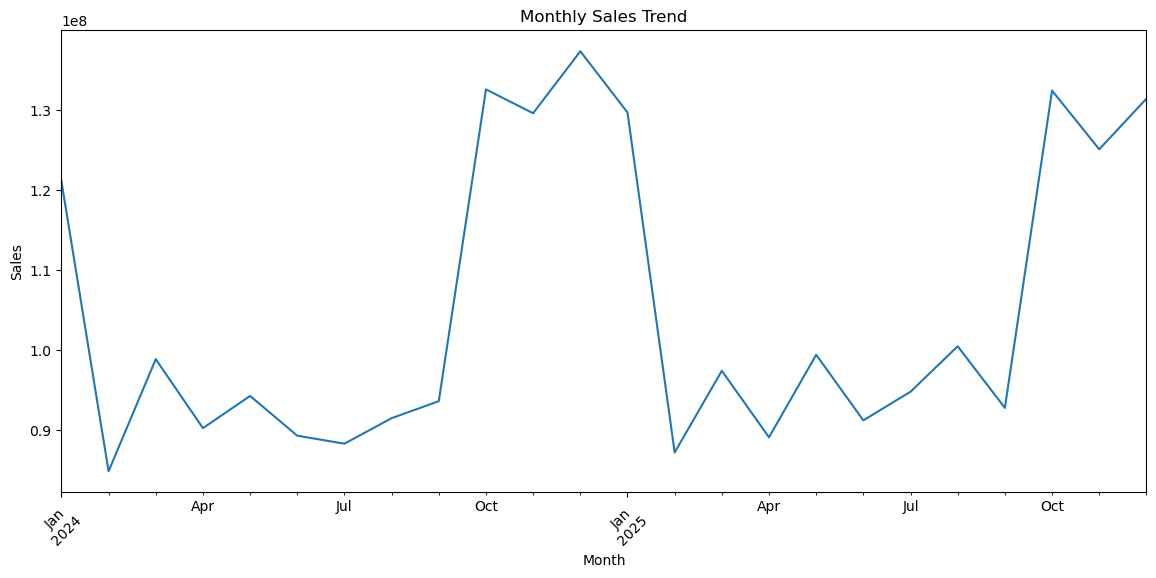

In [76]:
# MONTHLY SALES TREND

monthly_sales = (
    master_df
    .groupby(
        master_df["Order_Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)
monthly_sales.plot(
    figsize=(14,6),
    title="Monthly Sales Trend"
)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

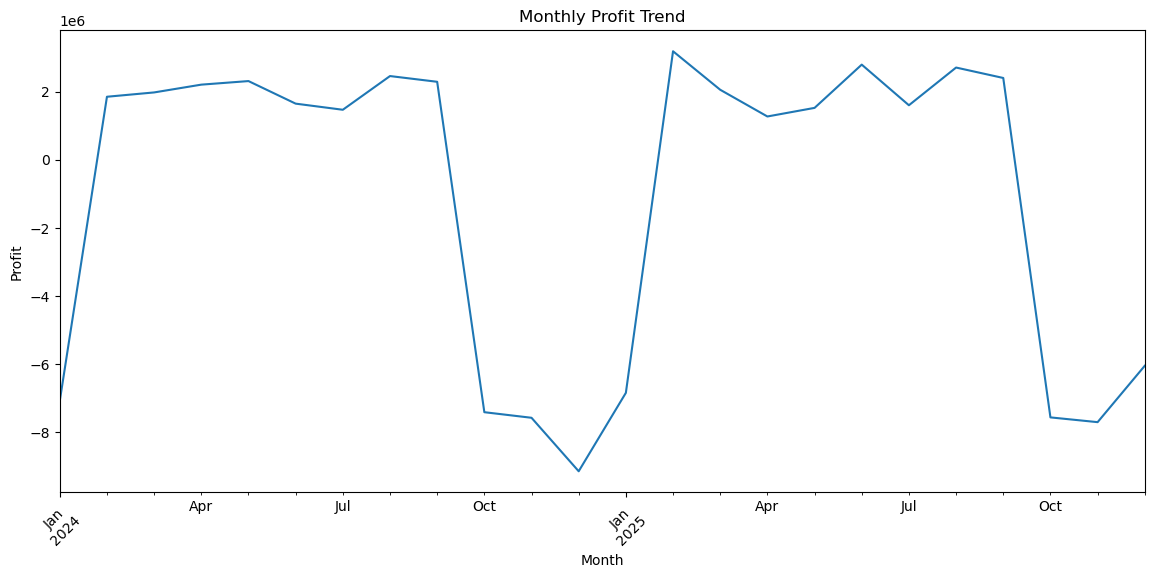

In [77]:
# MONTHLY PROFIT TREND

monthly_profit = (
    master_df
    .groupby(
        master_df["Order_Date"].dt.to_period("M")
    )["Profit"]
    .sum()
)
monthly_profit.plot(
    figsize=(14,6),
    title="Monthly Profit Trend"
)
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

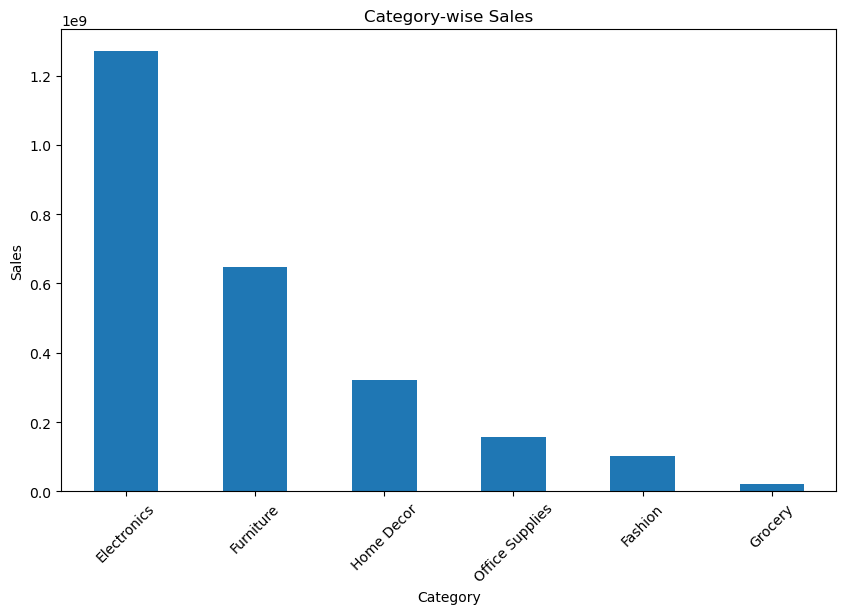

In [78]:
# CATEGORY SALES ANALYSIS

category_sales = (
    master_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
category_sales.plot(
    kind="bar",
    figsize=(10,6),
    title="Category-wise Sales"
)
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

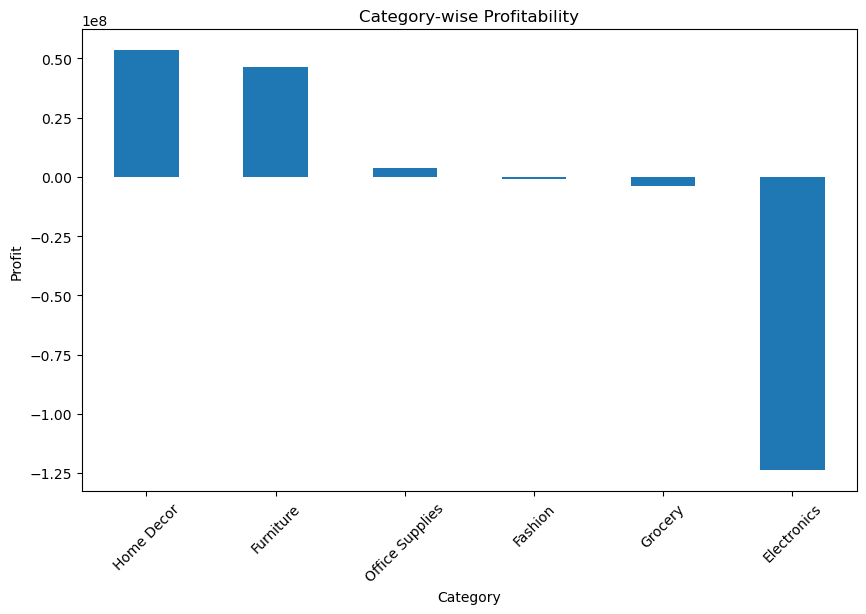

In [79]:
# CATEGORY PROFITABILITY ANALYSIS

category_profit = (
    master_df
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
category_profit.plot(
    kind="bar",
    figsize=(10,6),
    title="Category-wise Profitability"
)
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

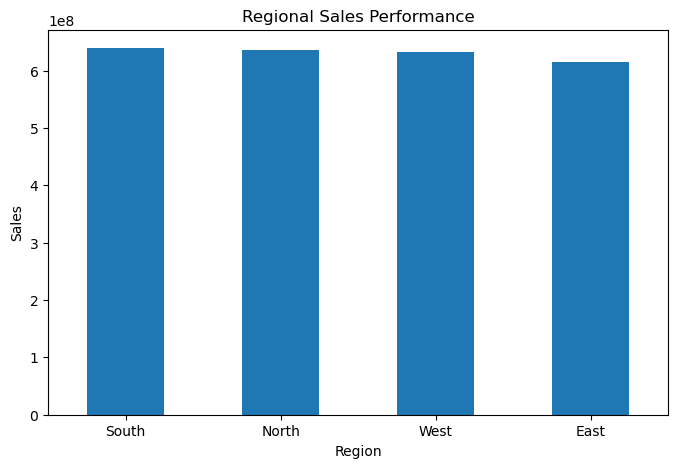

In [80]:
# REGIONAL SALES ANALYSIS

regional_sales = (
    master_df
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
regional_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Regional Sales Performance"
)
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

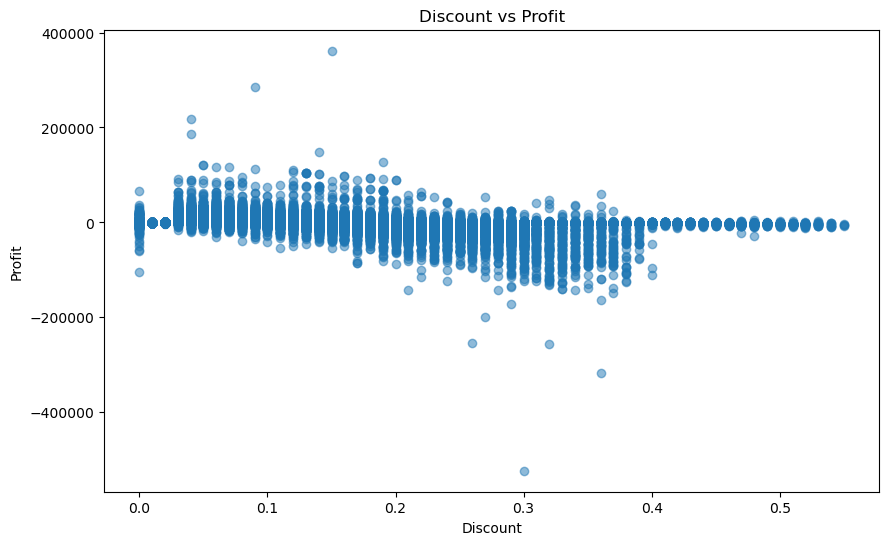

In [81]:
# DISCOUNT VS PROFIT ANALYSIS

plt.figure(figsize=(10,6))
plt.scatter(
    master_df["Discount"],
    master_df["Profit"],
    alpha=0.5
)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

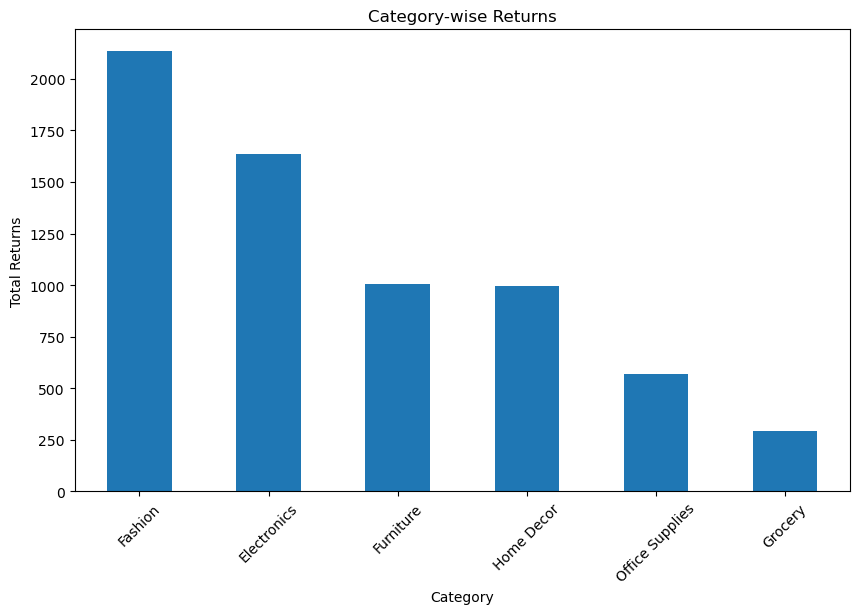

In [82]:
# RETURN ANALYSIS

return_analysis = (
    master_df
    .groupby("Category")["Return_ID"]
    .count()
    .sort_values(ascending=False)
)
return_analysis.plot(
    kind="bar",
    figsize=(10,6),
    title="Category-wise Returns"
)
plt.ylabel("Total Returns")
plt.xticks(rotation=45)
plt.show()

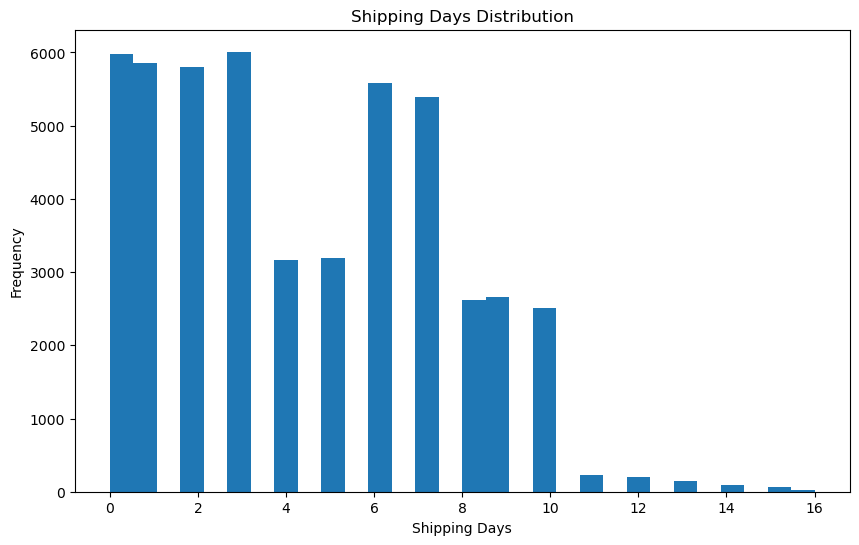

In [83]:
# SHIPPING DELAY ANALYSIS

master_df["Shipping_Days"].plot(
    kind="hist",
    bins=30,
    figsize=(10,6),
    title="Shipping Days Distribution"
)
plt.xlabel("Shipping Days")
plt.show()

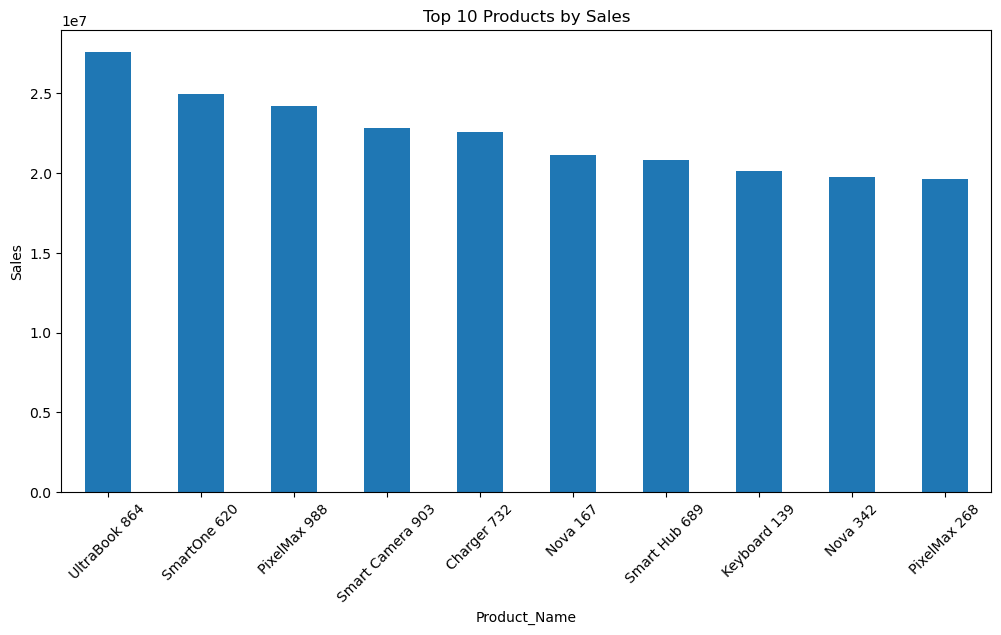

In [84]:
# TOP 10 PRODUCTS BY SALES

top_products = (
    master_df
    .groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products.plot(
    kind="bar",
    figsize=(12,6),
    title="Top 10 Products by Sales"
)
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

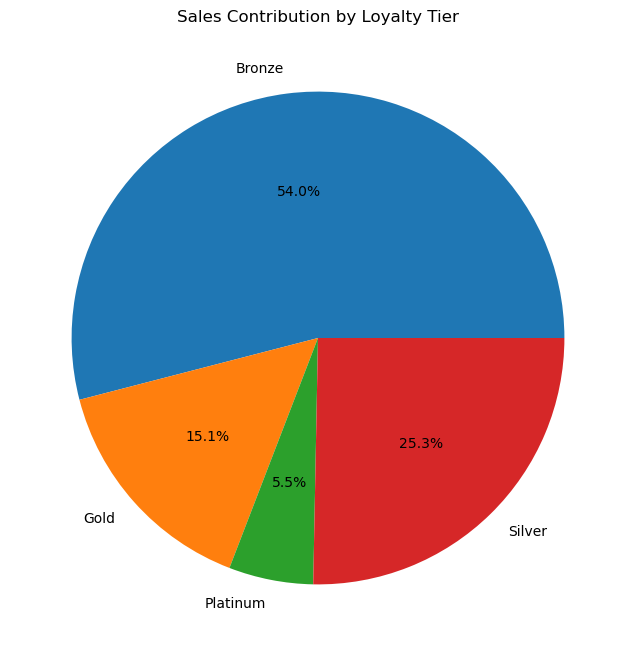

In [85]:
# LOYALTY TIER ANALYSIS

loyalty_sales = (
    master_df
    .groupby("Loyalty_Status")["Sales"]
    .sum()
)
loyalty_sales.plot(
    kind="pie",
    figsize=(8,8),
    autopct='%1.1f%%',
    title="Sales Contribution by Loyalty Tier"
)
plt.ylabel("")
plt.show()

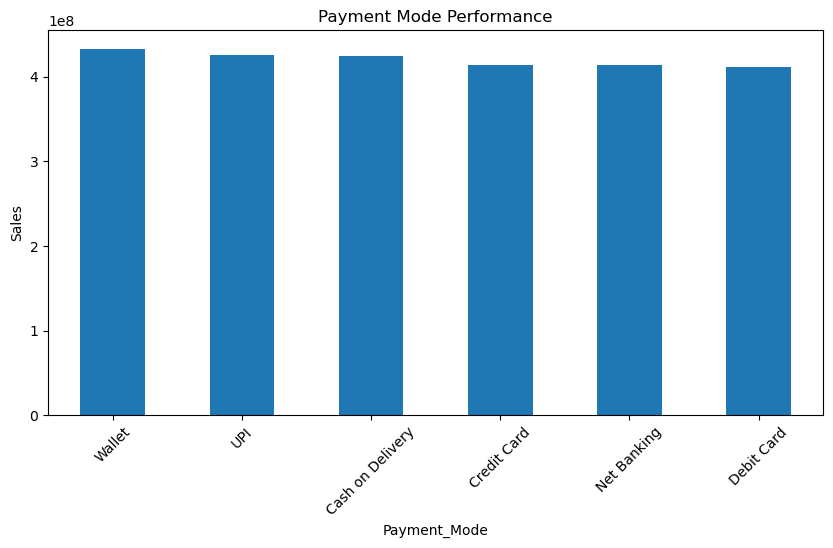

In [86]:
# PAYMENT MODE ANALYSIS

payment_analysis = (
    master_df
    .groupby("Payment_Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
payment_analysis.plot(
    kind="bar",
    figsize=(10,5),
    title="Payment Mode Performance"
)
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

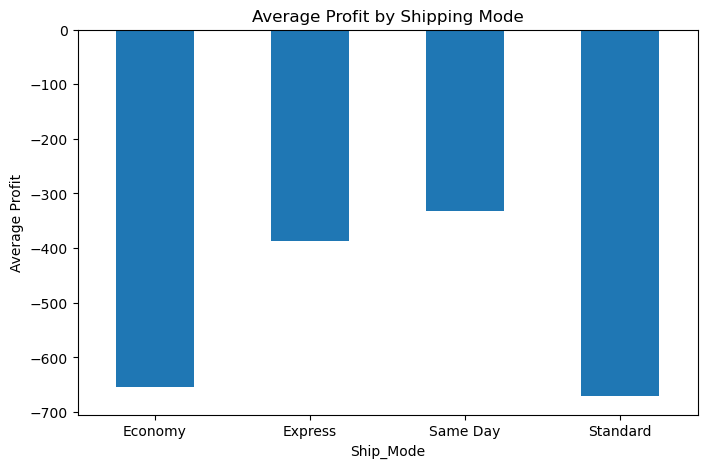

In [87]:
# SHIPPING MODE ANALYSIS

shipping_analysis = (
    master_df
    .groupby("Ship_Mode")["Profit"]
    .mean()
)
shipping_analysis.plot(
    kind="bar",
    figsize=(8,5),
    title="Average Profit by Shipping Mode"
)
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.show()

In [88]:
# SAVE CLEAN ANALYTICS DATASET

master_df.to_csv(
    "../outputs/master_analytics_dataset.csv",
    index=False
)

print("Master analytics dataset exported.")

Master analytics dataset exported.
